# Cell counts and signal colocalization

This notebook is intentionally a thin driver. Image reading, Cellpose segmentation, channel matching, per-cell measurements, summaries, and file export are implemented in the `colocalize` package.

Before the first run, install the environment with `pip install -r requirements.txt` from the project directory.

In [40]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
from colocalize import (
    AnalysisConfig,
    MaxProjection,
    ReferenceSet,
    SignalChannel,
    build_dataset,
    inspect_inputs,
    run_analysis,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Configuration

Channel numbers are zero-based. You may use metadata channel names instead (for example, `channel="DAPI"`) when the image format provides them. Add another `ReferenceSet` to segment a second reference definition with a different Cellpose model.

In [ ]:
config = AnalysisConfig(
    input_dir=Path(r"C:\Users\mzinn1\Desktop\DendrimerColocalization\TiledRetina\GD-RGC_small"),
    output_dir=Path(r"C:\Users\mzinn1\Desktop\DendrimerColocalization\TiledRetina\GD-RGC_small_counts"),
    reference_sets=[
        ReferenceSet(
            name="RPBMS",
            channel=1,
            model="cpdino_RPBMS-tiled",  # Auto-downloads from Hugging Face if needed
            diameter=None,   # Set expected diameter in pixels, or leave automatic
        ),
    ],
    signal_channels=[
        SignalChannel(
            name="GD",
            channel=0,
            threshold_method="percentile",  # calibrated from point annotations
            threshold_value=.995,
            positive_fraction_cutoff=.5,
        ),
    ],
    transforms=[
        MaxProjection(),
        # Add other transforms here; they run in order.
    ],
    exclude=("Map_A01.oir",),
    device="cuda",
    save_segmentation=True,  # Save grid + 4 panels for every input image
    # segmentation_output_dir=Path(r"C:\\path\\to\\segmentation-qc"),
    tile_size=(1024, 1024),
    stitch_masks=True,  # Whether to stitch tile masks into a single image
)

## Verify inputs

Confirm the discovered files, normalized `C × Y × X` shapes, and channel names before running Cellpose.

In [42]:
inputs = inspect_inputs(config)
inputs

,source,path,shape_cyx,channels
0,5214_5214_R_C003_C005_merged.tif,C:\Users\mzinn1\Desktop\DendrimerColocalizatio...,"(2, 7824, 8814)","(Channel:0:0, Channel:0:1)"
1,5217_5217_R_C003_C005_merged.tif,C:\Users\mzinn1\Desktop\DendrimerColocalizatio...,"(2, 9799, 8861)","(Channel:0:0, Channel:0:1)"


## Run analysis

The run writes `cells.csv`, `image_summary.csv`, and one label-mask TIFF per image/reference-set pair.

In [43]:
import warnings
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=UserWarning, module="cellpose")

result = run_analysis(config)

measuring tiles:   0%|          | 0/72 [00:00<?, ?tile/s]

Starting tile measuring for 5214_5214_R_C003_C005_merged.tif


Tile measuring complete for 5214_5214_R_C003_C005_merged.tif, starting saving segmentations


measuring tiles:   0%|          | 0/90 [00:00<?, ?tile/s]     

Starting tile measuring for 5217_5217_R_C003_C005_merged.tif


Tile measuring complete for 5217_5217_R_C003_C005_merged.tif, starting saving segmentations


In [44]:
display(result.images)
display(result.cells.head())

,source,reference_set,cell_count,total_cell_area_px,mean_cell_area_px,median_cell_area_px,signal_GD_positive_cell_count,mean_signal_GD_mean
0,5214_5214_R_C003_C005_merged.tif,RPBMS,31664,5255493,165.976914,170.0,31639,93.283621
1,5217_5217_R_C003_C005_merged.tif,RPBMS,46284,8725470,188.520223,184.0,46256,56.737391


,source,reference_set,tile_y,tile_x,cell_id,centroid_y,centroid_x,area_px,perimeter_px,equivalent_diameter_px,...,signal_GD_median,signal_GD_max,signal_GD_integrated,signal_GD_positive_area_px,signal_GD_positive_fraction,signal_GD_positive_cell,signal_GD_pearson_r,signal_GD_positive_jaccard,signal_GD_manders_m1_reference,signal_GD_manders_m2_signal
0,5214_5214_R_C003_C005_merged.tif,RPBMS,0,0,1,515.603659,932.408537,164,46.627417,14.450304,...,42.0,90.0,7088.0,164,1.0,True,-0.067576,0.823171,1.0,0.816733
1,5214_5214_R_C003_C005_merged.tif,RPBMS,0,0,2,540.804878,917.121951,41,21.899495,7.225152,...,45.0,78.0,1799.0,41,1.0,True,0.126854,0.97561,1.0,0.973874
2,5214_5214_R_C003_C005_merged.tif,RPBMS,0,0,3,586.779528,792.606299,127,43.213203,12.716187,...,67.0,128.0,8529.0,127,1.0,True,0.041446,1.0,1.0,1.0
3,5214_5214_R_C003_C005_merged.tif,RPBMS,0,0,4,603.121212,965.030303,33,20.485281,6.482045,...,56.0,131.0,2001.0,33,1.0,True,0.299289,1.0,1.0,1.0
4,5214_5214_R_C003_C005_merged.tif,RPBMS,0,0,5,797.198697,704.977199,307,64.284271,19.7708,...,60.0,144.0,18707.0,307,1.0,True,0.308943,0.915309,1.0,0.92746


## Optional segmentation quality check

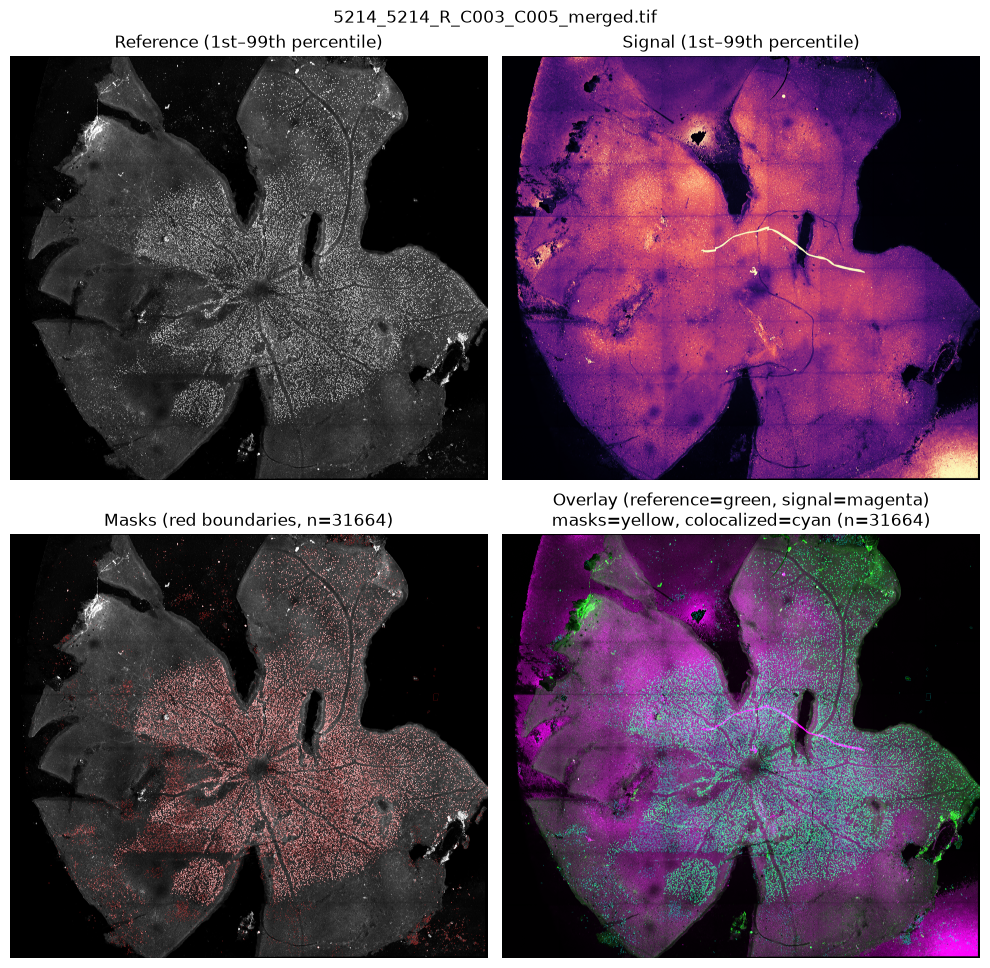

In [45]:
import tifffile
import importlib
from colocalize import visualization

importlib.reload(visualization)
img_number = 0
first_image = build_dataset(config, [inputs.iloc[img_number]["path"]])[0]
first_masks = tifffile.imread(result.mask_paths[img_number])
visualization.show_segmentation(
    first_image.channel(config.reference_sets[0].channel),
    first_masks,
    first_image.channel(config.signal_channels[0].channel),
    signal_spec=config.signal_channels[0],
    title=inputs.iloc[img_number]["source"],
);

### For Tiled Images

Image: 5214_5214_R_C003_C005_merged.tif  |  tile row=3 col=4  |  pixel origin y=3072 x=4096  |  1789 cells  |  1783 positive (99.7%)


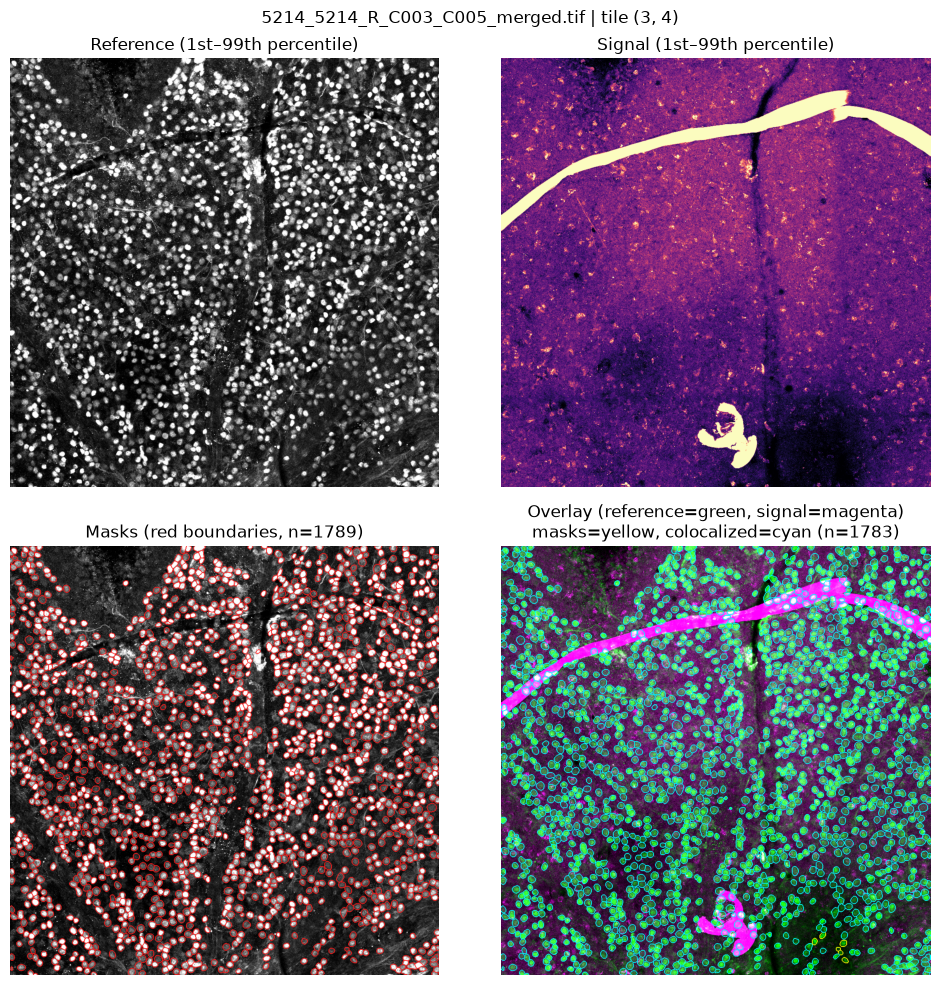

In [ ]:
import numpy as np
import tifffile
import importlib
from colocalize import visualization
from colocalize.colocalize import signal_threshold
from colocalize.readers import MicroscopyImage

importlib.reload(visualization)

img_number = 3   # image index (< len(inputs))
tile_row   = 3   # which row of tiles to inspect (0-based)
tile_col   = 4   # which column of tiles to inspect (0-based)

th, tw = config.tile_size
tile_y, tile_x = tile_row * th, tile_col * tw

full_image = build_dataset(config, [inputs.iloc[img_number]["path"]])[0]
full_masks = tifffile.imread(result.mask_paths[img_number])

# Crop both the image and the stitched mask to the selected tile region
tile_data  = full_image.data[:, tile_y : tile_y + th, tile_x : tile_x + tw]
tile_masks = full_masks[tile_y : tile_y + th, tile_x : tile_x + tw]
tile_image = MicroscopyImage(
    path=full_image.path, data=tile_data, channel_names=full_image.channel_names
)

spec        = config.signal_channels[0]
signal_img  = tile_image.channel(spec.channel)
thresh      = signal_threshold(signal_img, spec)
cell_labels = np.unique(tile_masks[tile_masks > 0])
n_cells     = len(cell_labels)
n_positive  = sum(
    np.mean(signal_img[tile_masks == lbl] > thresh) >= spec.positive_fraction_cutoff
    for lbl in cell_labels
)
pct = 100 * n_positive / n_cells if n_cells else 0.0

print(f"Image: {inputs.iloc[img_number]['source']}  |  "
      f"tile row={tile_row} col={tile_col}  |  "
      f"pixel origin y={tile_y} x={tile_x}  |  "
      f"{n_cells} cells  |  {n_positive} positive ({pct:.1f}%)")

visualization.show_segmentation(
    tile_image.channel(config.reference_sets[0].channel),
    tile_masks,
    tile_image.channel(config.signal_channels[0].channel),
    signal_spec=config.signal_channels[0],
    title=f"{inputs.iloc[img_number]['source']} | tile ({tile_row}, {tile_col})",
);


threshold=255  |  0/1789 positive (0.0%)  [method=percentile, value=99.5, cutoff=0.05]


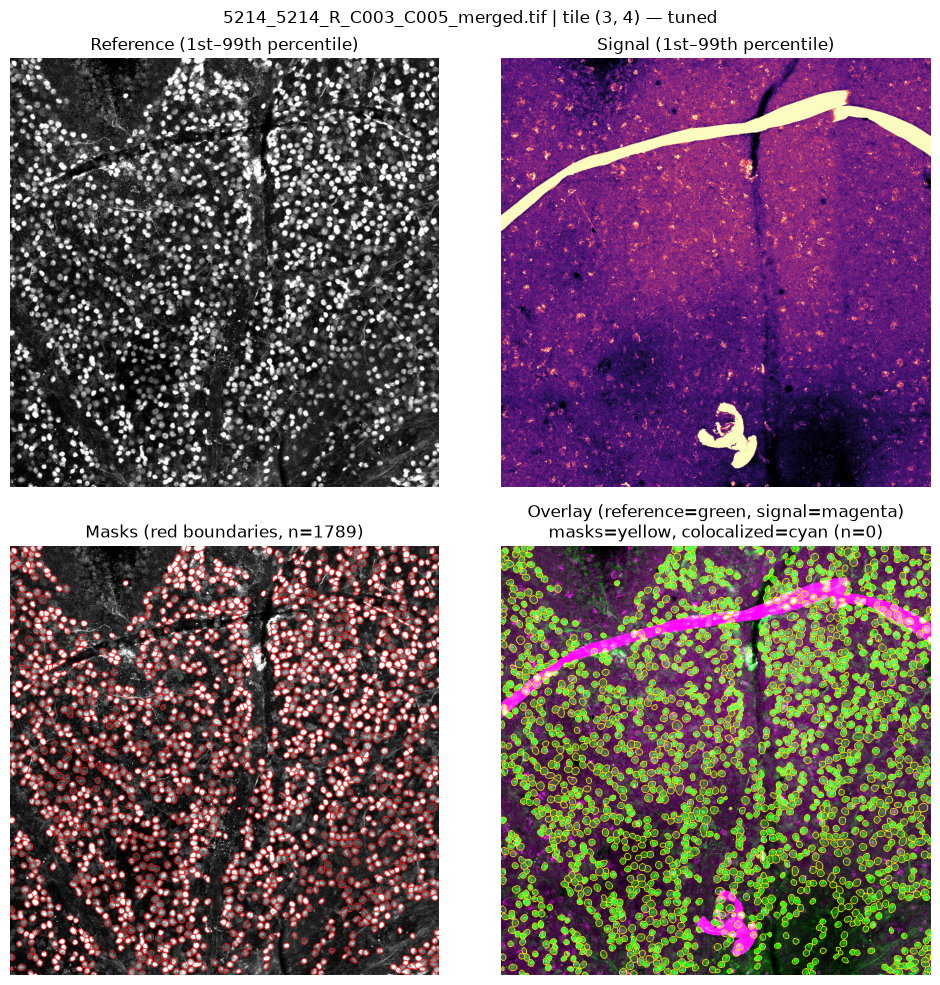

In [48]:
# --- Threshold tuning (reuses tile_image / tile_masks from the cell above) ---
from dataclasses import replace

threshold_method         = "percentile"   # "percentile" | "absolute" | "otsu" | "none"
threshold_value          = 99.5           # percentile (0-100) or absolute intensity
positive_fraction_cutoff = 0.05           # fraction of cell pixels that must be above threshold

tuned_spec = replace(
    config.signal_channels[0],
    threshold_method=threshold_method,
    threshold_value=threshold_value,
    positive_fraction_cutoff=positive_fraction_cutoff,
)

tuned_thresh      = signal_threshold(signal_img, tuned_spec)
tuned_n_positive  = sum(
    np.mean(signal_img[tile_masks == lbl] > tuned_thresh) >= tuned_spec.positive_fraction_cutoff
    for lbl in cell_labels
)
tuned_pct = 100 * tuned_n_positive / n_cells if n_cells else 0.0

print(f"threshold={tuned_thresh:.4g}  |  "
      f"{tuned_n_positive}/{n_cells} positive ({tuned_pct:.1f}%)  "
      f"[method={threshold_method}, value={threshold_value}, cutoff={positive_fraction_cutoff}]")

visualization.show_segmentation(
    tile_image.channel(config.reference_sets[0].channel),
    tile_masks,
    tile_image.channel(tuned_spec.channel),
    signal_spec=tuned_spec,
    title=f"{inputs.iloc[img_number]['source']} | tile ({tile_row}, {tile_col}) — tuned",
);
